# Vietnamese SBERT Embedding Test
So sánh `keepitreal/vietnamese-sbert` vs PhoBERT mean pooling
cho bài toán sentence similarity và TextRank summarization.

## 1. Cài đặt thư viện

In [1]:
!pip install sentence-transformers transformers torch scikit-learn numpy matplotlib seaborn networkx -q

## 2. Load cả 2 model để so sánh

In [2]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# --- Model 1: vietnamese-sbert ---
print("\nLoading keepitreal/vietnamese-sbert...")
sbert = SentenceTransformer("keepitreal/vietnamese-sbert")
sbert = sbert.to(device)
print("vietnamese-sbert loaded!")

# --- Model 2: PhoBERT (để so sánh) ---
print("\nLoading vinai/phobert-base-v2...")
phobert_tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2")
phobert_model = AutoModel.from_pretrained("vinai/phobert-base-v2")
phobert_model = phobert_model.to(device)
phobert_model.eval()
print("PhoBERT loaded!")

Device: cpu

Loading keepitreal/vietnamese-sbert...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


PhoBERT loaded!


## 3. Định nghĩa hàm embedding cho cả 2 model

In [3]:
def embed_sbert(text: str) -> np.ndarray:
    """
    Vietnamese-SBERT: fine-tuned cho sentence similarity.
    normalize_embeddings=True → cosine sim = dot product, nhanh hơn.
    """
    return sbert.encode(text, normalize_embeddings=True)


def embed_phobert_mean(text: str) -> np.ndarray:
    """
    PhoBERT mean pooling — strategy tốt nhất từ notebook trước.
    """
    inputs = phobert_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=256,
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = phobert_model(**inputs)

    mask = inputs["attention_mask"].unsqueeze(-1)\
                                   .expand(outputs.last_hidden_state.size())\
                                   .float()
    emb = torch.sum(outputs.last_hidden_state * mask, 1) \
          / torch.clamp(mask.sum(1), min=1e-9)
    return emb.squeeze(0).cpu().numpy()


def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9))


print("Functions ready!")

Functions ready!


## 4. Test nhanh shape và norm

In [4]:
test = "Hà Nội là thủ đô của Việt Nam"

emb_sbert  = embed_sbert(test)
emb_phobert = embed_phobert_mean(test)

print(f"vietnamese-sbert : shape={emb_sbert.shape},  norm={np.linalg.norm(emb_sbert):.4f}")
print(f"PhoBERT mean     : shape={emb_phobert.shape}, norm={np.linalg.norm(emb_phobert):.4f}")
print()
print("Note: sbert norm=1.0 vì đã normalize → cosine sim = dot product")

model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

vietnamese-sbert : shape=(768,),  norm=1.0000
PhoBERT mean     : shape=(768,), norm=5.0305

Note: sbert norm=1.0 vì đã normalize → cosine sim = dot product


## 5. So sánh cosine similarity — bài test chính

In [5]:
sentence_pairs = [
    ("Hà Nội hôm nay trời mưa to",
     "Thời tiết Hà Nội xấu, mưa lớn",
     "HIGH  - cùng chủ đề mưa Hà Nội"),

    ("Hà Nội hôm nay trời mưa to",
     "Người dân mang ô ra đường vì thời tiết xấu",
     "MED   - liên quan gián tiếp"),

    ("Hà Nội hôm nay trời mưa to",
     "Giá vàng tăng mạnh trong phiên giao dịch hôm nay",
     "LOW   - khác chủ đề hoàn toàn"),

    ("Trí tuệ nhân tạo đang thay đổi thế giới",
     "AI đang cách mạng hóa nhiều ngành công nghiệp",
     "HIGH  - cùng ý nghĩa, khác từ ngữ"),

    ("Trí tuệ nhân tạo đang thay đổi thế giới",
     "Bóng đá Việt Nam vô địch SEA Games",
     "LOW   - hoàn toàn khác"),

    ("Học sinh cần chăm chỉ học bài mỗi ngày",
     "Việc ôn luyện thường xuyên giúp học sinh tiến bộ",
     "HIGH  - cùng ý về học tập"),

    ("Học sinh cần chăm chỉ học bài mỗi ngày",
     "Công ty công nghệ đang tuyển dụng nhiều kỹ sư",
     "LOW   - khác hoàn toàn"),
]

print(f"{'Kỳ vọng':<40} {'SBERT':>8} {'PhoBERT':>8} {'Δ (SBERT-PhoBERT)':>18}")
print("-" * 80)

for sent_a, sent_b, label in sentence_pairs:
    s_score = cosine_sim(embed_sbert(sent_a),       embed_sbert(sent_b))
    p_score = cosine_sim(embed_phobert_mean(sent_a), embed_phobert_mean(sent_b))
    delta   = s_score - p_score
    flag    = "✓" if ("HIGH" in label and s_score > 0.75) or \
                     ("LOW"  in label and s_score < 0.50) else ""
    print(f"{label:<40} {s_score:>8.4f} {p_score:>8.4f} {delta:>+18.4f} {flag}")

Kỳ vọng                                     SBERT  PhoBERT  Δ (SBERT-PhoBERT)
--------------------------------------------------------------------------------
HIGH  - cùng chủ đề mưa Hà Nội             0.7569   0.7756            -0.0188 ✓
MED   - liên quan gián tiếp                0.4111   0.7039            -0.2928 
LOW   - khác chủ đề hoàn toàn              0.1674   0.6170            -0.4497 ✓
HIGH  - cùng ý nghĩa, khác từ ngữ          0.3964   0.7018            -0.3054 
LOW   - hoàn toàn khác                     0.1067   0.5309            -0.4241 ✓
HIGH  - cùng ý về học tập                  0.6074   0.8475            -0.2401 
LOW   - khác hoàn toàn                     0.1348   0.6611            -0.5263 ✓


## 6. Visualize: Phân tách HIGH vs LOW

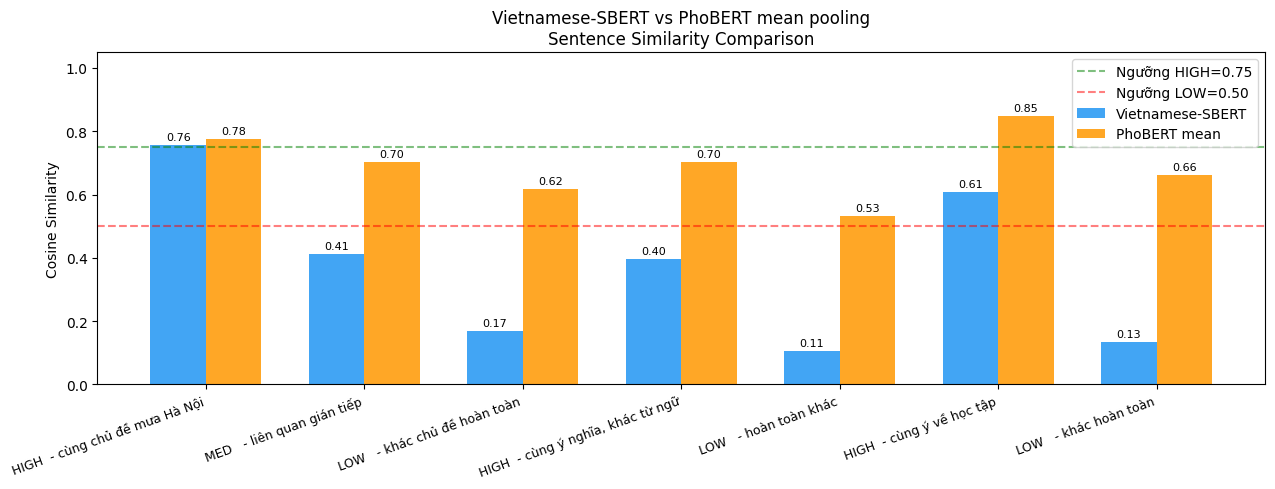

Saved: sbert_vs_phobert_similarity.png


In [6]:
import matplotlib.pyplot as plt

labels_short = [p[2][:35] for p in sentence_pairs]
sbert_scores  = [cosine_sim(embed_sbert(a), embed_sbert(b)) for a, b, _ in sentence_pairs]
phobert_scores = [cosine_sim(embed_phobert_mean(a), embed_phobert_mean(b)) for a, b, _ in sentence_pairs]

x = np.arange(len(labels_short))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, sbert_scores,  width, label="Vietnamese-SBERT", color="#2196F3", alpha=0.85)
bars2 = ax.bar(x + width/2, phobert_scores, width, label="PhoBERT mean",     color="#FF9800", alpha=0.85)

ax.set_ylabel("Cosine Similarity")
ax.set_title("Vietnamese-SBERT vs PhoBERT mean pooling\nSentence Similarity Comparison")
ax.set_xticks(x)
ax.set_xticklabels(labels_short, rotation=20, ha="right", fontsize=9)
ax.set_ylim(0, 1.05)
ax.axhline(y=0.75, color="green", linestyle="--", alpha=0.5, label="Ngưỡng HIGH=0.75")
ax.axhline(y=0.50, color="red",   linestyle="--", alpha=0.5, label="Ngưỡng LOW=0.50")
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("sbert_vs_phobert_similarity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sbert_vs_phobert_similarity.png")

## 7. Similarity Matrix — heatmap N×N

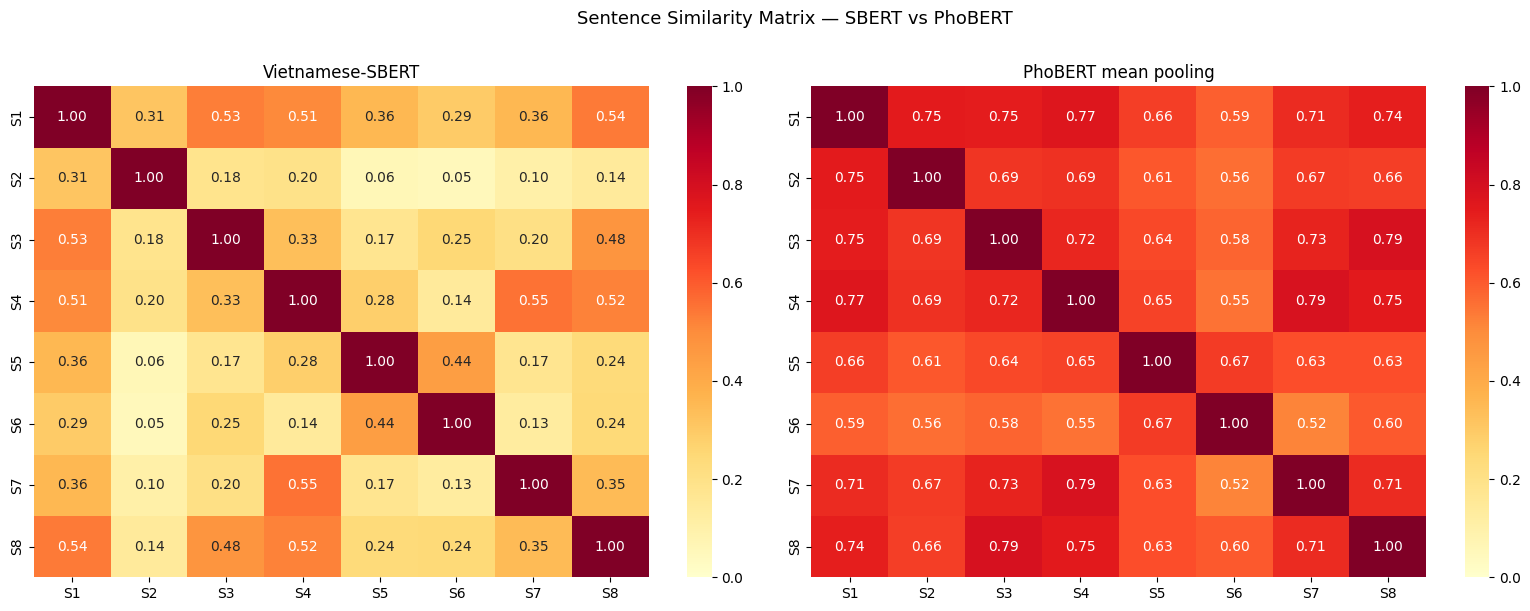


Các câu:
  S1: Hà Nội là thủ đô và là thành phố lớn nhất Việt Nam.
  S2: Thành phố có dân số hơn 8 triệu người và diện tích hơn 3000 km2.
  S3: Hà Nội có nhiều di tích lịch sử nổi tiếng như Hồ Gươm và Văn Miếu.
  S4: Kinh tế Hà Nội phát triển mạnh với nhiều khu công nghiệp.
  S5: Thời tiết Hà Nội có 4 mùa rõ rệt: xuân, hạ, thu, đông.
  S6: Mùa đông Hà Nội thường lạnh và có mưa phùn.
  S7: Giao thông Hà Nội đang được cải thiện với nhiều tuyến metro mới.
  S8: Hà Nội có nhiều trường đại học danh tiếng.

SBERT   — mean=0.2908, std=0.1505, min=0.0471, max=0.5513
PhoBERT — mean=0.6717, std=0.0725, min=0.5176, max=0.7921

Note: std cao hơn = phân biệt câu tốt hơn


In [7]:
import seaborn as sns

sentences = [
    "Hà Nội là thủ đô và là thành phố lớn nhất Việt Nam.",
    "Thành phố có dân số hơn 8 triệu người và diện tích hơn 3000 km2.",
    "Hà Nội có nhiều di tích lịch sử nổi tiếng như Hồ Gươm và Văn Miếu.",
    "Kinh tế Hà Nội phát triển mạnh với nhiều khu công nghiệp.",
    "Thời tiết Hà Nội có 4 mùa rõ rệt: xuân, hạ, thu, đông.",
    "Mùa đông Hà Nội thường lạnh và có mưa phùn.",
    "Giao thông Hà Nội đang được cải thiện với nhiều tuyến metro mới.",
    "Hà Nội có nhiều trường đại học danh tiếng.",
]

def build_sim_matrix(sentences, embed_fn):
    embs = [embed_fn(s) for s in sentences]
    n = len(embs)
    mat = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            mat[i][j] = cosine_sim(embs[i], embs[j])
    return mat

mat_sbert   = build_sim_matrix(sentences, embed_sbert)
mat_phobert = build_sim_matrix(sentences, embed_phobert_mean)

labels = [f"S{i+1}" for i in range(len(sentences))]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, mat, title in zip(
    axes,
    [mat_sbert, mat_phobert],
    ["Vietnamese-SBERT", "PhoBERT mean pooling"]
):
    sns.heatmap(
        mat, ax=ax,
        xticklabels=labels, yticklabels=labels,
        annot=True, fmt=".2f",
        cmap="YlOrRd", vmin=0, vmax=1
    )
    ax.set_title(title, fontsize=12)

plt.suptitle("Sentence Similarity Matrix — SBERT vs PhoBERT", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("similarity_matrix_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nCác câu:")
for i, s in enumerate(sentences):
    print(f"  S{i+1}: {s}")

# Thống kê phân tán
off_diag_sbert   = mat_sbert[~np.eye(len(sentences), dtype=bool)]
off_diag_phobert = mat_phobert[~np.eye(len(sentences), dtype=bool)]
print(f"\nSBERT   — mean={off_diag_sbert.mean():.4f}, std={off_diag_sbert.std():.4f}, min={off_diag_sbert.min():.4f}, max={off_diag_sbert.max():.4f}")
print(f"PhoBERT — mean={off_diag_phobert.mean():.4f}, std={off_diag_phobert.std():.4f}, min={off_diag_phobert.min():.4f}, max={off_diag_phobert.max():.4f}")
print("\nNote: std cao hơn = phân biệt câu tốt hơn")

## 8. TextRank với 2 model — so sánh summary

In [8]:
import networkx as nx
import math

def textrank(sentences, embed_fn, top_k=3, threshold=0.0):
    """
    TextRank chuẩn: similarity matrix → PageRank → top-k câu.
    """
    embs = [embed_fn(s) for s in sentences]
    n = len(embs)

    sim_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                s = cosine_sim(embs[i], embs[j])
                sim_matrix[i][j] = s if s > threshold else 0.0

    graph  = nx.from_numpy_array(sim_matrix)
    scores = nx.pagerank(graph, weight="weight")

    ranked      = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    top_indices = sorted([idx for idx, _ in ranked[:top_k]])
    return [(scores[i], sentences[i]) for i in top_indices]


def word_overlap_textrank(sentences, top_k=3):
    """TextRank gốc Mihalcea & Tarau 2004 — baseline."""
    def overlap(s1, s2):
        w1, w2 = set(s1.lower().split()), set(s2.lower().split())
        common = w1 & w2
        if not common:
            return 0.0
        return len(common) / (math.log(len(w1)+1) + math.log(len(w2)+1))

    n = len(sentences)
    sim_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                sim_matrix[i][j] = overlap(sentences[i], sentences[j])

    graph  = nx.from_numpy_array(sim_matrix)
    scores = nx.pagerank(graph, weight="weight")
    ranked      = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    top_indices = sorted([idx for idx, _ in ranked[:top_k]])
    return [(scores[i], sentences[i]) for i in top_indices]


# --- Test ---
configs = [
    ("TextRank gốc (Word Overlap)",    lambda s: word_overlap_textrank(s, top_k=3)),
    ("PhoBERT mean pooling TextRank",  lambda s: textrank(s, embed_phobert_mean, top_k=3)),
    ("Vietnamese-SBERT TextRank",      lambda s: textrank(s, embed_sbert,        top_k=3)),
]

for title, fn in configs:
    print("=" * 60)
    print(title)
    print("=" * 60)
    for score, sent in fn(sentences):
        print(f"  [{score:.4f}] {sent}")
    print()

TextRank gốc (Word Overlap)
  [0.1560] Hà Nội có nhiều di tích lịch sử nổi tiếng như Hồ Gươm và Văn Miếu.
  [0.1459] Mùa đông Hà Nội thường lạnh và có mưa phùn.
  [0.1410] Hà Nội có nhiều trường đại học danh tiếng.

PhoBERT mean pooling TextRank
  [0.1311] Hà Nội là thủ đô và là thành phố lớn nhất Việt Nam.
  [0.1294] Hà Nội có nhiều di tích lịch sử nổi tiếng như Hồ Gươm và Văn Miếu.
  [0.1301] Kinh tế Hà Nội phát triển mạnh với nhiều khu công nghiệp.

Vietnamese-SBERT TextRank
  [0.1712] Hà Nội là thủ đô và là thành phố lớn nhất Việt Nam.
  [0.1513] Kinh tế Hà Nội phát triển mạnh với nhiều khu công nghiệp.
  [0.1497] Hà Nội có nhiều trường đại học danh tiếng.



## 9. Đo thời gian inference — so sánh tốc độ

In [9]:
import time

test_sentences = sentences * 5  # 40 câu
N_RUNS = 3

def benchmark(name, embed_fn, sents):
    times = []
    for _ in range(N_RUNS):
        t0 = time.time()
        for s in sents:
            embed_fn(s)
        times.append(time.time() - t0)
    avg = np.mean(times)
    print(f"{name:<35} {avg:.3f}s cho {len(sents)} câu  ({avg/len(sents)*1000:.1f}ms/câu)")

print(f"Benchmark trên {len(test_sentences)} câu, trung bình {N_RUNS} lần:\n")
benchmark("Vietnamese-SBERT",      embed_sbert,         test_sentences)
benchmark("PhoBERT mean pooling",  embed_phobert_mean,  test_sentences)

Benchmark trên 40 câu, trung bình 3 lần:

Vietnamese-SBERT                    12.568s cho 40 câu  (314.2ms/câu)
PhoBERT mean pooling                4.791s cho 40 câu  (119.8ms/câu)


## 10. Test với văn bản của bạn

In [10]:
your_text = """
Trí tuệ nhân tạo đang ngày càng được ứng dụng rộng rãi trong nhiều lĩnh vực của cuộc sống.
Trong y tế, AI giúp chẩn đoán bệnh chính xác hơn và phát hiện sớm các khối u ung thư.
Nông nghiệp thông minh sử dụng AI để tối ưu hóa việc tưới tiêu và dự báo mùa vụ.
Trong giáo dục, các hệ thống học tập cá nhân hóa giúp học sinh tiếp thu kiến thức hiệu quả hơn.
Tuy nhiên, AI cũng đặt ra nhiều thách thức về đạo đức và việc làm trong tương lai.
Nhiều chuyên gia lo ngại rằng tự động hóa sẽ thay thế hàng triệu việc làm truyền thống.
Các chính phủ đang nỗ lực xây dựng khung pháp lý để quản lý sự phát triển của AI.
Nhìn chung, AI là công cụ mạnh mẽ nếu được sử dụng đúng cách và có trách nhiệm.
"""

sents = [s.strip() for s in your_text.strip().split('\n') if s.strip()]
print(f"Tổng số câu: {len(sents)}\n")

for title, fn in [
    ("TextRank gốc",           lambda s: word_overlap_textrank(s, top_k=3)),
    ("SBERT TextRank",         lambda s: textrank(s, embed_sbert, top_k=3)),
]:
    print(f"--- {title} ---")
    for score, sent in fn(sents):
        print(f"  • {sent}")
    print()

Tổng số câu: 8

--- TextRank gốc ---
  • Trong y tế, AI giúp chẩn đoán bệnh chính xác hơn và phát hiện sớm các khối u ung thư.
  • Nông nghiệp thông minh sử dụng AI để tối ưu hóa việc tưới tiêu và dự báo mùa vụ.
  • Tuy nhiên, AI cũng đặt ra nhiều thách thức về đạo đức và việc làm trong tương lai.

--- SBERT TextRank ---
  • Trí tuệ nhân tạo đang ngày càng được ứng dụng rộng rãi trong nhiều lĩnh vực của cuộc sống.
  • Tuy nhiên, AI cũng đặt ra nhiều thách thức về đạo đức và việc làm trong tương lai.
  • Nhìn chung, AI là công cụ mạnh mẽ nếu được sử dụng đúng cách và có trách nhiệm.

